In [2]:
import importlib
import kline_2day_forecaster.three_class_forecaster
import kline_2day_forecaster

importlib.reload(kline_2day_forecaster.three_class_forecaster)
importlib.reload(kline_2day_forecaster)

from kline_2day_forecaster import (
    ForecastConfig,
    train_three_class_forecaster,
)

In [33]:
config = ForecastConfig(
    input_csv="DataAPI/data/TQQQ_5M.csv",
    output_dir="outputs/tqqq_xgboost_three_class_1pct",
    symbol="TQQQ",

    horizon_days=1,

    enable_chan=False,
    use_standard_technical_features=True,
    use_chan_bsp_features=False,

    regular_session_only=True,
    regular_session_start="09:30",
    regular_session_end="15:55",
    sample_every_minutes=15,

    train_start_date="2018-01-01",
    train_end_date="2019-12-31",

    validation_fraction=0.20,

    test_start_date="2023-01-01",
    test_end_date="2023-06-30",

    technical_windows=(
        6,    # 30 minutes
        12,   # 1 hour
        39,   # half session
        78,   # one session
        156,  # two sessions
        #390,  # one week
    ),

    technical_rsi_periods=(12, 39, 78, 156),
    #technical_atr_periods=(12, 39, 78, 156),

    # exclude_features=(
    #     "tech_atr_*",
    # ),

    technical_macd_periods=(
        (12, 26, 9),
        (39, 78, 20),
        (78, 156, 39),
    ),

    technical_stochastic_period=39,
    technical_stochastic_d_period=10,
    technical_williams_period=39,
    technical_cci_period=78,
    technical_mfi_period=39,
    technical_bollinger_period=78,
    technical_dmi_period=39,
    technical_adx_period=20,
    technical_rsl_period=39,
    technical_ppo_periods=(39, 78),

    technical_first_hour_minutes=60,

    technical_relative_volume_lookback_days=20,
    technical_relative_volume_min_days=5,
)

In [30]:
result = train_three_class_forecaster(
    config,

    down_threshold=-0.02,
    up_threshold=0.02,

    # The ±3% classes are already reasonably balanced.
    class_weighting="balanced",

    # exclude_features=(
    #     "tech_atr_*",
    #     "tech_volatility_*",
    #     "tech_keltner_width_*",
    #     "tech_starc_width_*",
    #     "tech_bollinger_bandwidth_*",
    #     "tech_previous_day_*",
    # ),

    xgboost_params={
        "n_estimators": 300,
        "max_depth": 5,
        "learning_rate": 0.02,
        "subsample": 0.65,
        "colsample_bytree": 0.50,
        "min_child_weight": 200,
        "reg_alpha": 1.0,
        "reg_lambda": 20.0,
        "n_jobs": 1,
    },
)

result

[Data] Loading DataAPI/data/TQQQ_5M.csv
[Data] Loaded 609,449 normalized rows: 2010-02-11 09:40:00 to 2026-06-12 19:55:00
[Data] Working period including warm-up: 2017-12-26 08:00:00 to 2023-07-03 16:55:00 (250,317 rows)
[Features] Calculating causal price/volume technical features
[Chan] Disabled
[Labels] Building targets through the same time 1 trading sessions later
[Data] Dataset ready: 250,317 rows, 113 columns, 239,990 labeled | 3.2s
[Three-class] test accuracy=0.3353, balanced accuracy=0.3534, macro F1=0.3327, AUC=0.5299 | elapsed=6.7s


{'model_path': 'outputs\\tqqq_xgboost_three_class_1pct\\three_class_model.joblib',
 'predictions_path': 'outputs\\tqqq_xgboost_three_class_1pct\\three_class_test_predictions.csv',
 'metrics': {'thresholds': {'down': -0.02, 'up': 0.02},
  'class_weighting': 'balanced',
  'excluded_feature_patterns': [],
  'excluded_features': [],
  'rows': {'train': 10407, 'validation': 2609, 'test': 3224},
  'splits': {'train': {'rows': 10407,
    'accuracy': 0.7002978764293264,
    'balanced_accuracy': 0.708620965476908,
    'macro_f1': 0.6939399481514849,
    'log_loss': 0.8159175730730464,
    'confusion_matrix': [[1759, 403, 194], [791, 3497, 860], [293, 578, 2032]],
    'actual_class_counts': {'down': 2356, 'neutral': 5148, 'up': 2903},
    'predicted_class_counts': {'down': 2843, 'neutral': 4478, 'up': 3086},
    'per_class': {'down': {'precision': 0.6187126275061555,
      'recall': 0.7466044142614601,
      'f1-score': 0.6766685901134833,
      'support': 2356.0},
     'neutral': {'precision': 

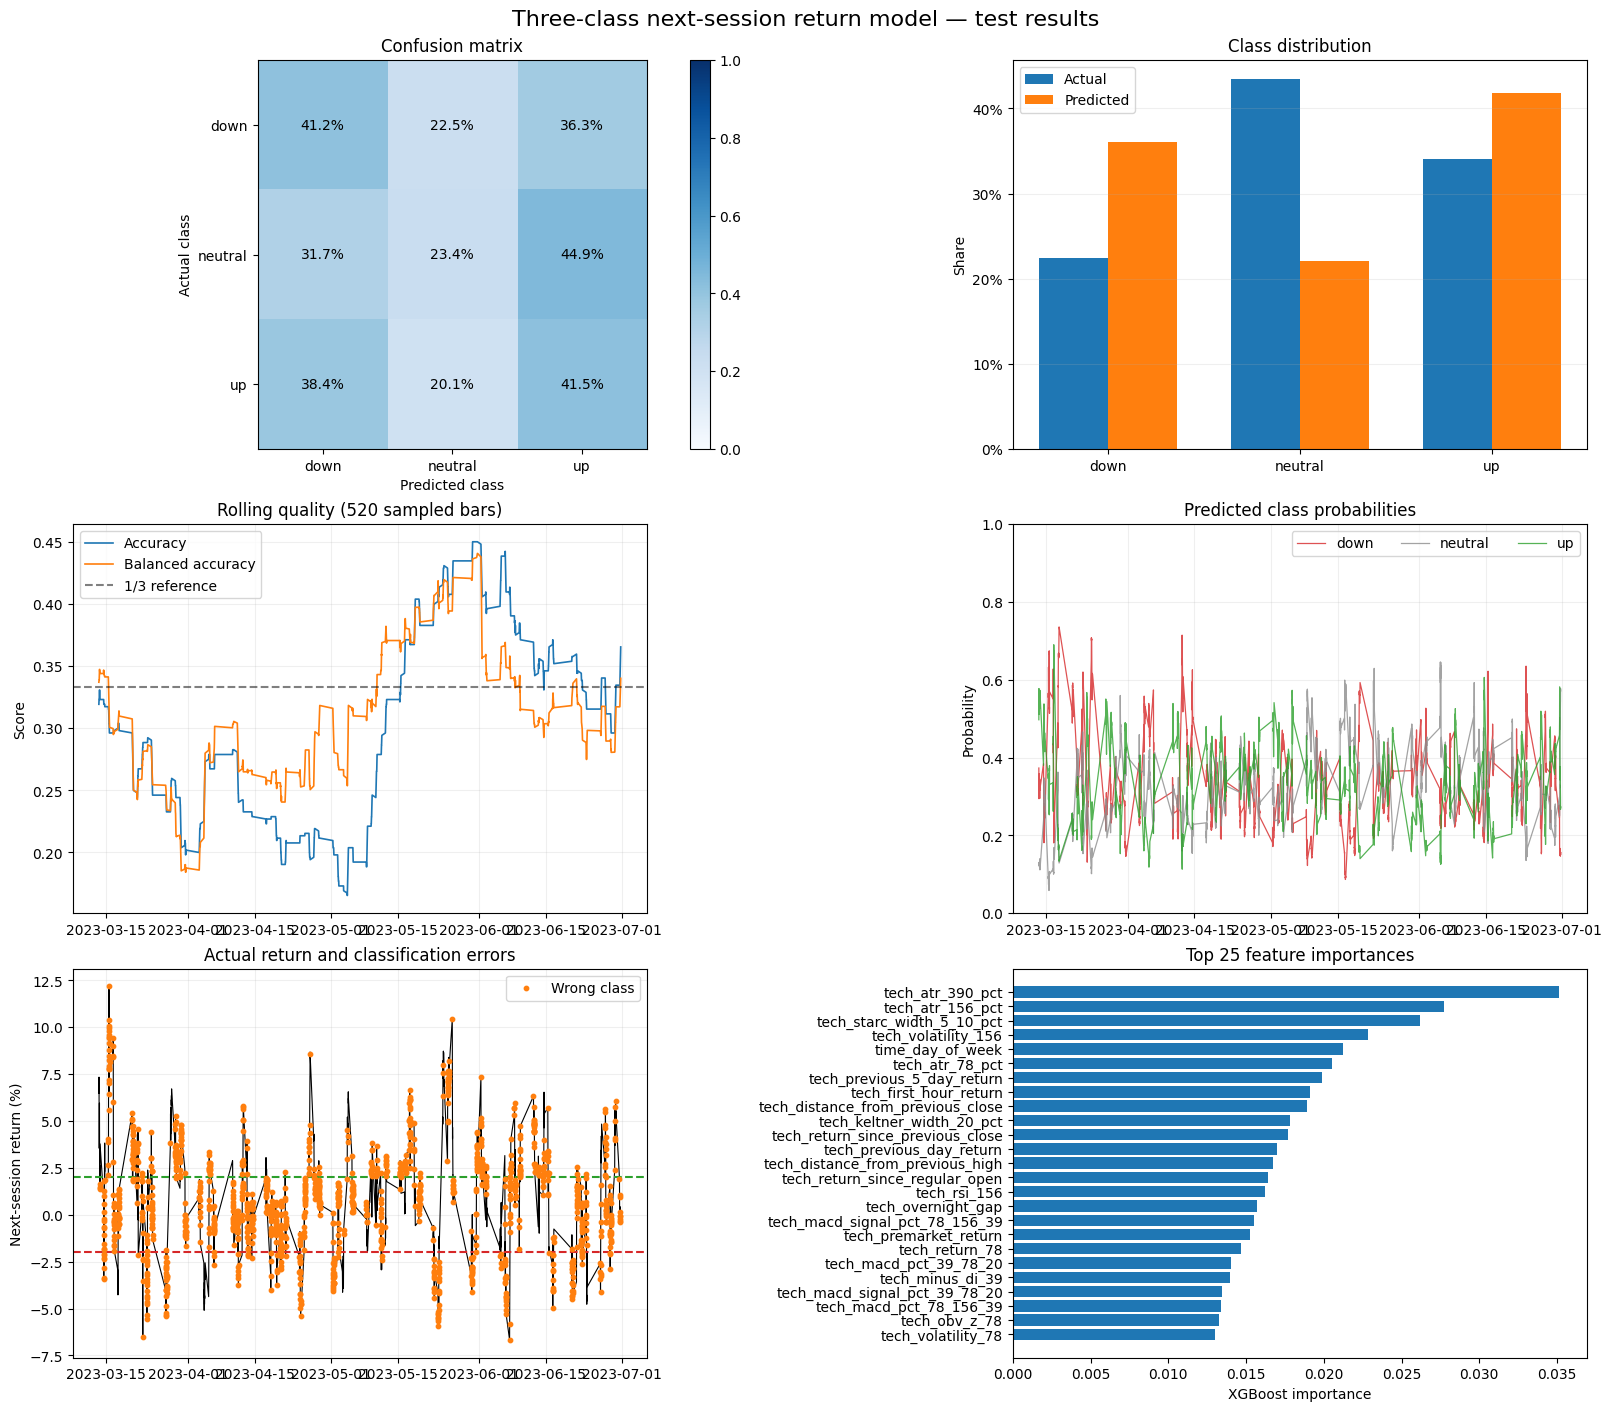

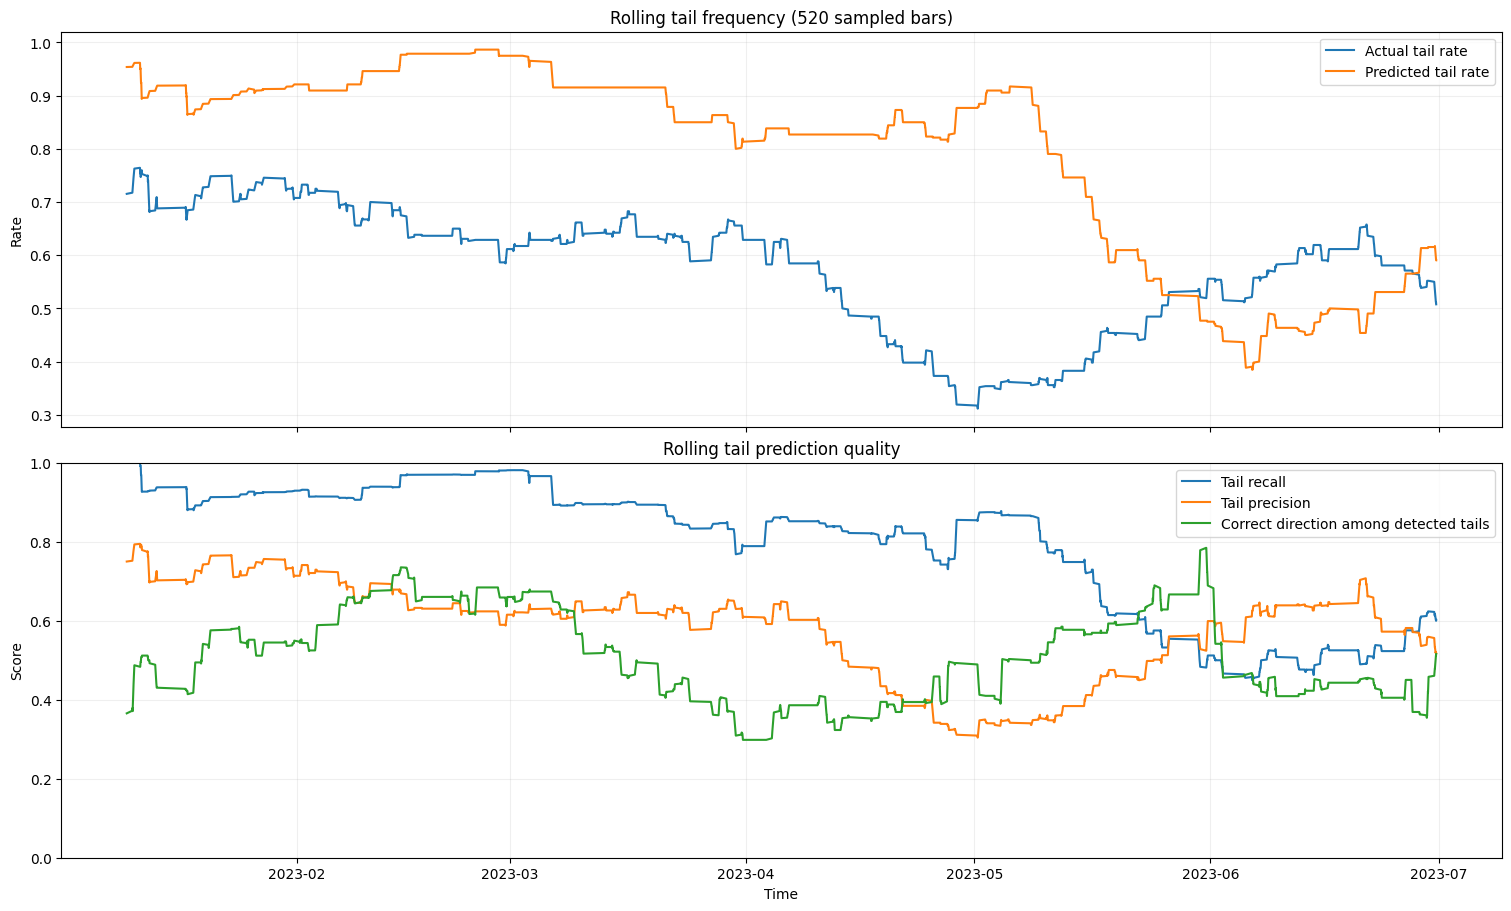

({'figure': <Figure size 1600x1400 with 7 Axes>,
  'plot_path': 'outputs\\tqqq_xgboost_three_class_1pct\\three_class_results.png',
  'rolling_quality_path': 'outputs\\tqqq_xgboost_three_class_1pct\\three_class_rolling_quality.csv'},
 {'figure': <Figure size 1500x900 with 2 Axes>,
  'plot_path': 'outputs\\tqqq_xgboost_three_class_1pct\\three_class_tail_quality.png'})

In [31]:
import importlib
import kline_2day_forecaster.three_class_evaluation
import kline_2day_forecaster

importlib.reload(kline_2day_forecaster.three_class_evaluation)
importlib.reload(kline_2day_forecaster)

from kline_2day_forecaster import (
    plot_three_class_results,
    plot_three_class_tail_quality,
)

results_plot = plot_three_class_results(
    "outputs/tqqq_xgboost_three_class_1pct",
    rolling_bars=520,       # About 20 trading days at 15-minute sampling
    max_time_points=2_000,
    top_features=25,
    normalize_confusion=True,
    show=True,
)

tail_plot = plot_three_class_tail_quality(
    "outputs/tqqq_xgboost_three_class_1pct",
    rolling_bars=520,
    show=True,
)

results_plot, tail_plot

[Data] Loading DataAPI/data/TQQQ_5M.csv
[Data] Loaded 609,449 normalized rows: 2010-02-11 09:40:00 to 2026-06-12 19:55:00
[Data] Working period including warm-up: 2017-12-26 08:00:00 to 2023-07-03 16:55:00 (250,317 rows)
[Features] Calculating causal price/volume technical features
[Chan] Disabled
[Labels] Building targets through the same time 1 trading sessions later
[Data] Dataset ready: 250,317 rows, 113 columns, 239,990 labeled | 3.2s


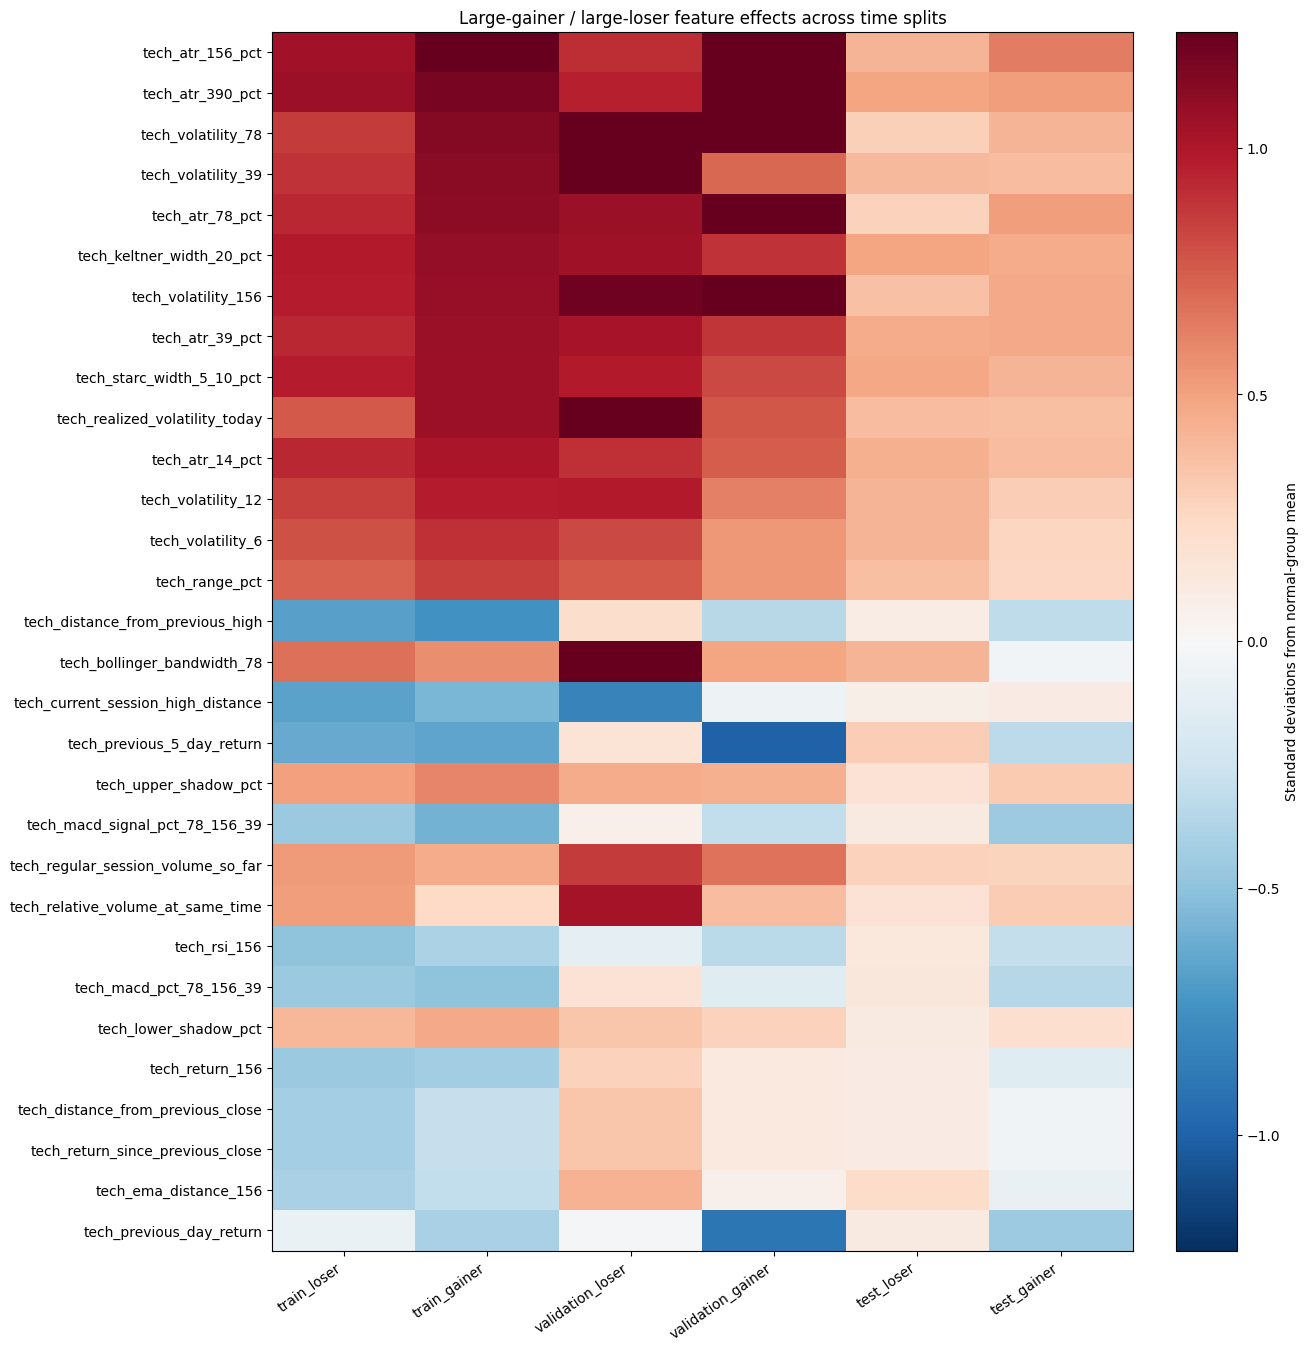

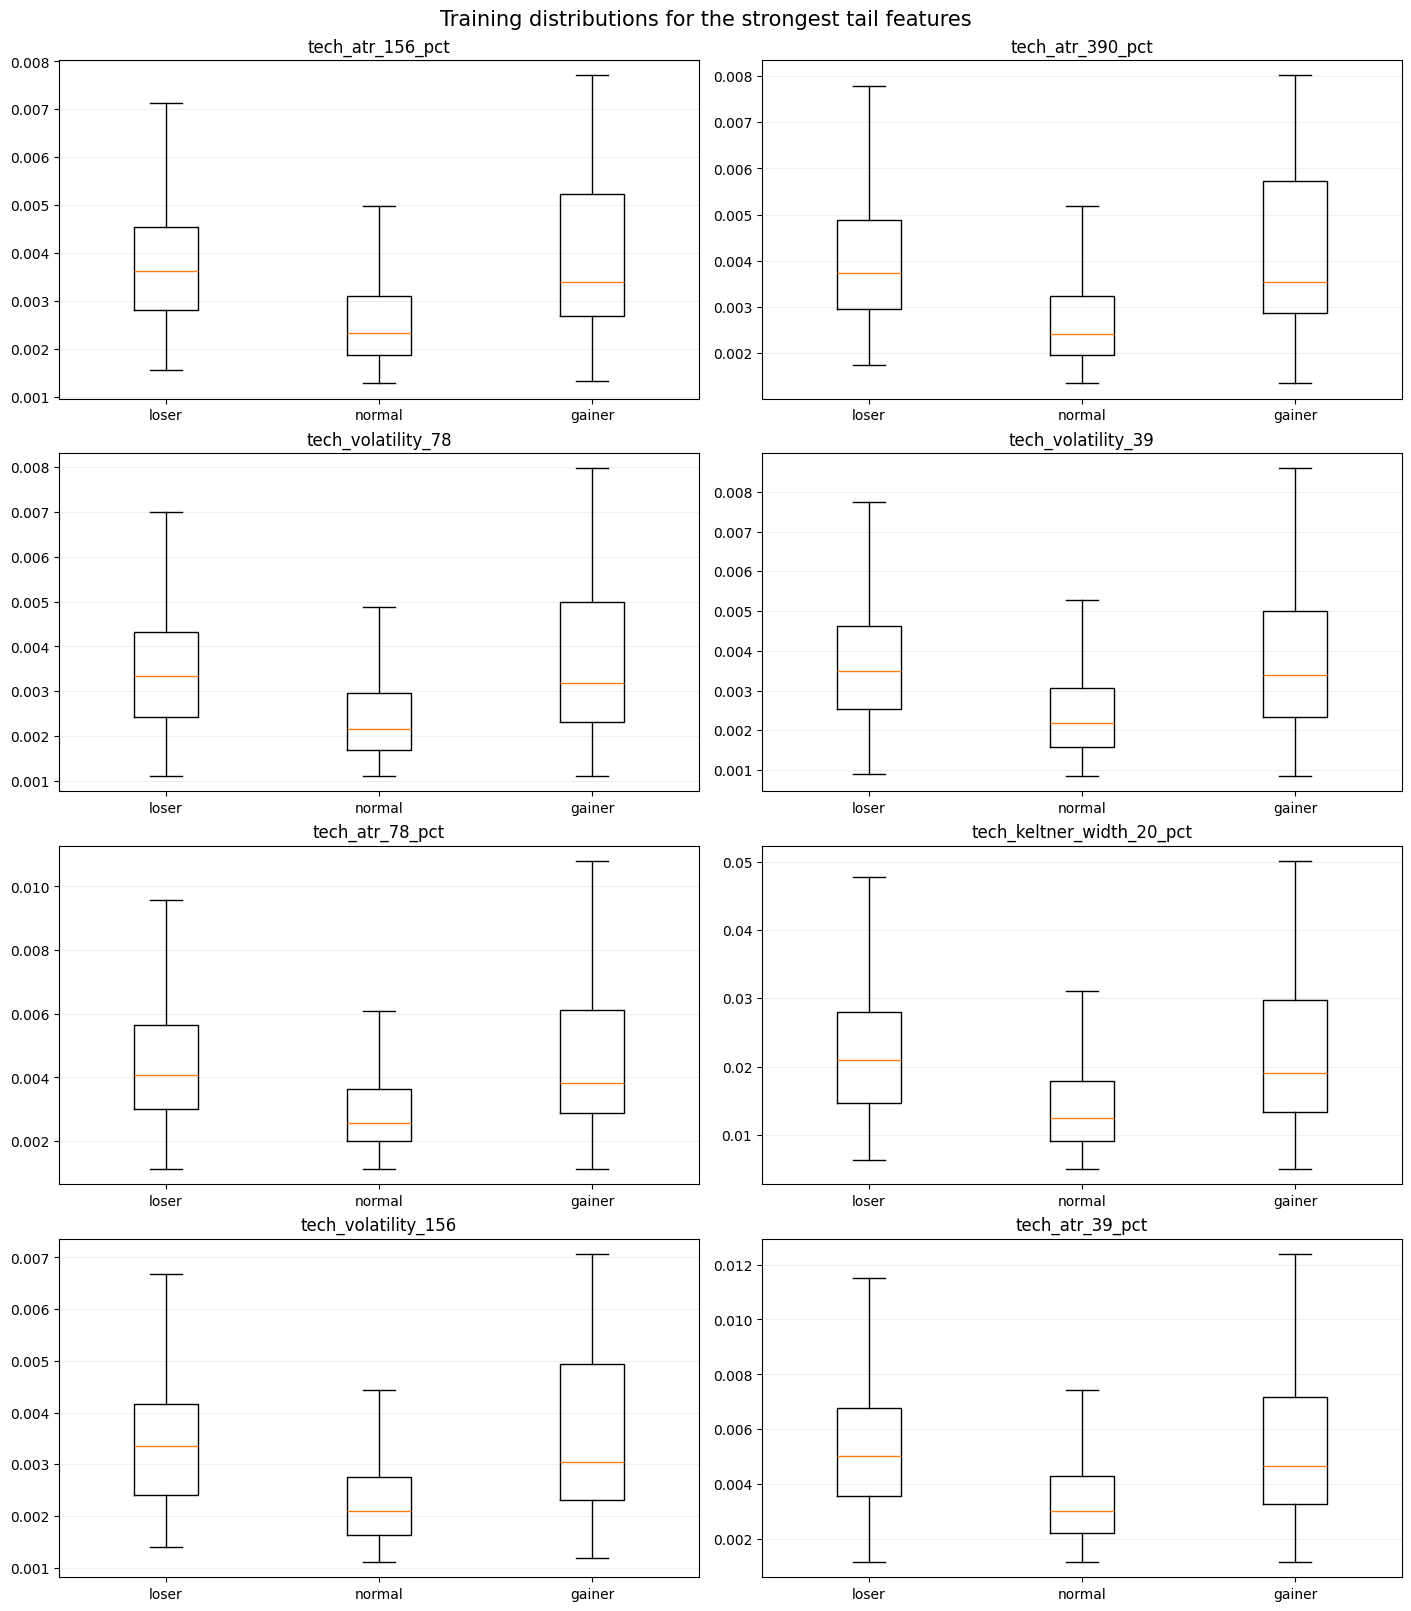

{'down': -0.04691709294692781, 'up': 0.041782389728495815}

In [32]:
import importlib
import kline_2day_forecaster.tail_feature_analysis
import kline_2day_forecaster

importlib.reload(kline_2day_forecaster.tail_feature_analysis)
importlib.reload(kline_2day_forecaster)

from kline_2day_forecaster import analyze_tail_feature_profiles

analysis = analyze_tail_feature_profiles(
    "outputs/tqqq_xgboost_three_class_1pct",

    lower_quantile=0.10,  # Bottom 10% = top losers
    upper_quantile=0.90,  # Top 10% = top gainers

    top_features=30,
    distribution_features=8,
    show=True,
)

analysis["thresholds"]